In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm
from pickle import load, dump
import matplotlib.pyplot as plt
import seaborn as sns

import re
import os
import nltk
import time
from dotenv import load_dotenv
from datetime import datetime
from itertools import chain
from collections import Counter
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Yavanash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
load_dotenv()

True

In [35]:
# filepath = "data.csv" #this is for colab
filepath = "../data/data.csv" # this is for jupyter
vocab_path = "../data/vocab.pkl" # this is for jupyter
checkpoint_path = "../checkpoints/checkpt200.pth"
PAD = "<PAD>"
SOS = "<SOS>"
EOS = "<EOS>"
UNK = "<UNK>"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
def preprocess(text):
        words = word_tokenize(text.lower())
        cleaned = [word for word in words if re.match(r"[a-z0-9+.,?!']", word)]
        return cleaned

In [12]:
articles = ["gighe egie gieg eige wjgie wijeg", "weiohg ebw ww wof qiq djdqn"]
[preprocess(t) for t in articles]

[['gighe', 'egie', 'gieg', 'eige', 'wjgie', 'wijeg'],
 ['weiohg', 'ebw', 'ww', 'wof', 'qiq', 'djdqn']]

In [13]:
class Vocab():
    def __init__(self, min_freq):
        self.itos = {0:PAD, 1:SOS, 2:EOS, 3:UNK}
        self.stoi = {PAD:0, SOS:1, EOS:2, UNK:3}
        self.freqs = {}
        self.count = 4
        self.min_freq = min_freq

    def build_vocab(self, corpus):
        #corpus is a list of words
        self.freqs = Counter(corpus)
        for word, freq in self.freqs.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.stoi[word] = self.count
                self.itos[self.count] = word
                self.count += 1

In [14]:
class NewsDataset(Dataset):
    def __init__(self, filepath, vocab_path=None):
        super().__init__()
        df = pd.read_csv(filepath)

        articles = df["article"].tolist()
        self.article = [preprocess(t) for t in articles]
        summary = df["text"].tolist()
        self.summary = [preprocess(t) for t in summary]

        self.corpus = chain.from_iterable(self.article + self.summary)

        self.vocab = Vocab(min_freq=5)
        if vocab_path == None:
          self.vocab.build_vocab(self.corpus)

        else:
            with open(vocab_path, 'rb') as f:
                self.vocab = load(f)

    def __len__(self):
        return len(self.article)

    def __getitem__(self, idx):
        article = [self.vocab.stoi.get(word, self.vocab.stoi[UNK]) for word in self.article[idx]] #list of words in article
        summary = [self.vocab.stoi[SOS]] + [self.vocab.stoi.get(word, self.vocab.stoi[UNK]) for word in self.summary[idx]]#list of words in summary
        #add sos

        summary += [self.vocab.stoi[EOS]]
        article_tensor = torch.tensor(article, dtype=torch.long)
        summary_tensor = torch.tensor(summary, dtype=torch.long)
        return article_tensor, summary_tensor

In [15]:
def test_data(input_article, input_summary, vocab):
    a = preprocess(input_article)
    s = preprocess(input_summary)
    article = [vocab.stoi.get(word, vocab.stoi[UNK]) for word in a] #list of words in article
    summary = [vocab.stoi[SOS]] + [vocab.stoi.get(word, vocab.stoi[UNK]) for word in s]#list of words in summary
    #add sos

    if len(article) > 600:
        article = article[:600]

    if len(summary) > 100:
        summary = summary[:100]

    summary += [vocab.stoi[EOS]]
    article_tensor = torch.tensor(article, dtype=torch.long)
    summary_tensor = torch.tensor(summary, dtype=torch.long)
    return article_tensor, summary_tensor

In [16]:
data = NewsDataset(filepath, vocab_path=None)
# data = NewsDataset(filepath, vocab_path=vocab_path)

In [17]:
VOCAB_SIZE = data.vocab.count
HIDDEN_SIZE = 128
MAX_LEN = 32
VOCAB_SIZE, device

(19197, device(type='cpu'))

In [19]:
# with open(vocab_path, 'wb') as file:
#     dump(data.vocab, file)

In [20]:
from torch.nn.utils.rnn import pad_sequence

#pads for entire batch at once
def padding(batch):
    article, summary = zip(*batch)
    article_batched = pad_sequence(article, batch_first=True, padding_value=0)
    summary_batched = pad_sequence(summary, batch_first=True, padding_value=0)

    return article_batched, summary_batched

In [21]:
train_loader = DataLoader(data, batch_size=32, collate_fn=padding, drop_last=True)
a,b = next(iter(train_loader))
a.shape, b.shape

(torch.Size([32, 1305]), torch.Size([32, 77]))

In [22]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(0.1)
        self.bigru = nn.GRU(hidden_size, hidden_size, batch_first=True, bidirectional=True)
        self.out = nn.Linear(2*hidden_size, hidden_size)

    def forward(self, article):
        embed = self.dropout(self.embed(article))
        output, hidden = self.bigru(embed) #hidden = [2,bs,hidden] out = [bs, seqlen, 2*hidden]
        h = torch.cat((hidden[0], hidden[1]), dim=-1)
        hidden = self.out(h).unsqueeze(0)
        return output, hidden

In [23]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.wa = nn.Linear(hidden_size, hidden_size)
        self.va = nn.Linear(2*hidden_size, hidden_size)
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, s_prev, keys, mask):
        #query = decoder_prev , keys = encoder_all
        #s_prev = [num_layers, bs, hidden]
        query = s_prev.permute(1,0,2)
        scores = self.V(torch.tanh(self.wa(query) + self.va(keys)))
        scores = scores.masked_fill(mask == 0, -1e9) # scores = [32, seqlen, 1], mask = [32, seqlen, 1]
        alpha = torch.softmax(scores, dim=1)
        alpha = alpha.permute(0,2,1)
        # print(alpha.shape, keys.shape)
        context = torch.bmm(alpha, keys) # batch matrix multiplication
        return context, alpha

In [24]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.gru = nn.GRU(3*hidden_size, hidden_size, batch_first=True)
        self.attn = Attention(hidden_size)
        self.out = nn.Linear(3*hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.1)

    def forward(self, encoder_outputs, encoder_hidden, mask, target_tensor=None):
        decoder_input = torch.empty(encoder_outputs.shape[0], 1, dtype=torch.long).fill_(1).to(device) # sos = 1
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attention_wts = []

        if target_tensor is not None:
            for i in range(1,target_tensor.shape[1]):
                decoder_output, decoder_hidden, attn_wts = self.forward_step(decoder_input, decoder_hidden, encoder_outputs, mask)
                attention_wts.append(attn_wts.detach())
                decoder_outputs.append(decoder_output)

                decoder_input = target_tensor[:,i].unsqueeze(-1)

        else:
            for i in range(MAX_LEN):
                decoder_output, decoder_hidden, attn_wts = self.forward_step(decoder_input, decoder_hidden, encoder_outputs)
                attention_wts.append(attn_wts)
                decoder_outputs.append(decoder_output)

                topv,topi = decoder_output.topk(k=1,dim=-1) #dim=-1 -> vocab size , topi = [bs, 1, 1]
                decoder_input = topi.squeeze(-1).detach()

        outputs = torch.cat(decoder_outputs, dim=1)
        #outputs = [32, seqlen, vocab_size]
        return outputs, decoder_hidden, attention_wts

    def forward_step(self, decoder_input, decoder_hidden, encoder_outputs, mask):
        embed = self.dropout(self.embed(decoder_input))
        #s(t-1) = decoder_hidden
        #hn = encoder_outputs

        context, wts = self.attn(decoder_hidden, encoder_outputs, mask)
        # print(context.shape)

        input = torch.cat((embed, context), dim=-1)
        # print(input.shape, decoder_hidden.shape)
        out, hidden = self.gru(input, decoder_hidden)
        out_with_attn = torch.cat((out, context), dim=-1)

        #out = [bs,seqlen,hidden] context = [bs,1,2*hidden] since
        #context = alpha*keys alpha=[bs,1,seqlen] keys=[bs,seqlen,2*hidden]
        # print(out_with_attn.shape, out.shape, context.shape)
        out = self.out(out_with_attn)
        return out, hidden, wts

In [25]:
encoder = Encoder(VOCAB_SIZE, HIDDEN_SIZE)
# o,h=encoder(a)
# a.shape,o.shape, h.shape

In [26]:
decoder = Decoder(VOCAB_SIZE, HIDDEN_SIZE)
# out, _, _ = decoder(o,h,b)

In [52]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, article, summary=None):
        encoder_outputs, encoder_hidden = self.encoder(article)
        #attention mask for padding
        mask = (article != data.vocab.stoi[PAD]) # mask = [32, seqlen], scores = [32, seqlen, 1]
        mask = mask.unsqueeze(-1)
        decoder_outputs, decoder_hidden, attn = self.decoder(encoder_outputs, encoder_hidden, mask, summary)

        return outputs, attn

In [28]:
model = Seq2Seq(encoder, decoder)
criterion = nn.CrossEntropyLoss(ignore_index=data.vocab.stoi[PAD])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [53]:
def train_one_epoch(model, data, criterion, optimizer):
    train_losses = []
    last_attn = None
    progress = tqdm(data, total=len(data))

    for article, summary in progress:
        # print(article.shape, summary.shape)
        if article.shape[1] > 300:
          article = article[:,:300]
        article, summary = article.to(device), summary.to(device)
        # print(article.shape, summary.shape)
        outputs, attn = model(article, summary)
        outputs = outputs.view(-1, VOCAB_SIZE)
        targets = summary[:,1:].reshape(-1)#match sos of output to w1 of target
        #Crossentropyloss expects logits as input and not softmax; the given below shapes are the norm for inputs to loss
        loss = criterion(outputs, targets)
        train_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        last_attn = attn

    return sum(train_losses) / len(train_losses), last_attn

In [30]:
def get_summary(output_tensor, vocab):
    idx = [torch.argmax(word) for word in output_tensor]
    summary = " ".join([vocab.itos[i.item()] for i in idx])
    return summary

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
import os
save_dir = '/content/drive/MyDrive/checkpts/'
os.makedirs(save_dir, exist_ok=True)

In [31]:
def save_checkpoint(model, optimizer, attn, epoch, loss):
    checkpoint = {
        'epoch': epoch,
        'attn':attn,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    filepath = os.path.join(save_dir, f"checkpt{epoch}.pth")
    torch.save(checkpoint, filepath)

    old_checkpoint = os.path.join(save_dir, f"checkpt{epoch-1}.pth")
    if os.path.exists(old_checkpoint):
        os.remove(old_checkpoint)
    print(f"Checkpoint saved to {filepath} at epoch {epoch}")

In [32]:
def load_checkpoint(model, checkpt):
    return torch.load(checkpt, map_location=device)

In [51]:
EPOCHS = 200

training_losses = []
print(f"Starting Training...")
last_attn = None
model.to(device)

encoder.train()
decoder.train()
for epoch in range(1,EPOCHS+1):
    strt = time.time()
    print(f"Start time: {datetime.now()}")
    loss, attn = train_one_epoch(model, train_loader, criterion, optimizer)
    end = time.time()
    training_losses.append(loss)
    print(f"Epoch {epoch}: Loss = {loss} | Time Taken = {end-strt} seconds")
    save_checkpoint(model, optimizer, attn, epoch, train_losses)
    last_attn = attn

Starting Training...
Start time: 2026-03-12 19:54:17.481481


  1%|▌                                                                                 | 1/141 [00:09<21:07,  9.05s/it]


KeyboardInterrupt: 

In [36]:
checkpt = load_checkpoint(model, checkpoint_path)
checkpt.keys()
attn_keys = checkpt["attn"]
train_losses = checkpt["loss"]

Text(0.5, 1.0, 'Training Loss')

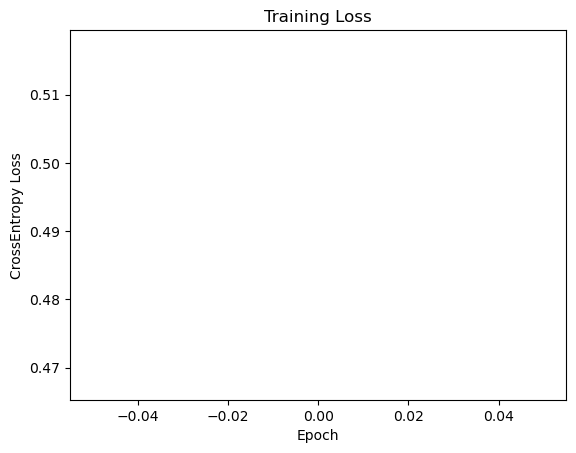

In [38]:
plt.plot(train_losses, ls=":")
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.title("Training Loss")

<Axes: >

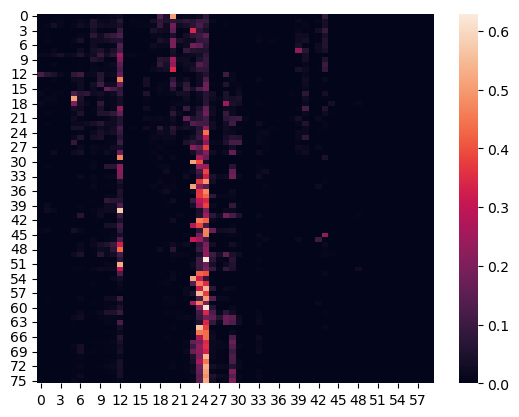

In [44]:
# last_attn[0].shape
# len(attn_keys)
attn_matrix = torch.cat([sentence for sentence in attn_keys], dim=1)
attn_matrix.shape
sns.heatmap(attn_matrix[0,:,:60].detach().cpu())
# attn_matrix.sum(dim=1)

In [45]:
a = "Artificial intelligence is becoming increasingly important in healthcare. Hospitals are using machine learning systems to help doctors analyze medical images such as X-rays and MRIs. These systems can detect patterns that might be difficult for humans to notice, which helps in identifying diseases like cancer at an early stage. AI is also used to predict patient risk, manage hospital resources, and assist in drug discovery. However, experts warn that AI systems should always be used alongside human medical judgment because incorrect predictions could lead to serious consequences."
b = "AI is helping healthcare by analyzing medical images, predicting patient risks, and assisting in drug discovery, but human oversight remains essential."

In [46]:
a,b = next(iter(train_loader))

In [47]:
vocab = data.vocab
# at,bt = test_data(a,b,vocab)
# at.shape, bt.shape
# out, _ = model(at.unsqueeze(0).to(device),bt.unsqueeze(0).to(device))
out, _ = model(a.to(device),b.to(device))

In [50]:
out.shape

torch.Size([2432, 19197])

In [49]:
# get_summary(out, vocab)
# get_summary(b, vocab)
# get_summary(a, vocab)

In [ ]:
# Use "!" to run shell commands in Colab
!git config --global user.email "yavanashsarma@gmail.com"
!git config --global user.name "Yavanash"
token = os.getenv("PAT_token")